In [1]:
from kilosort.io import load_ops
from kilosort.data_tools import (
    mean_waveform, cluster_templates, get_good_cluster, get_cluster_spikes,
    get_spike_waveforms, get_best_channels, get_labels, get_templates,
    )
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

from pathlib import Path


In [19]:
def compute_isi(spike_times_sec):
    return np.diff(np.sort(spike_times_sec))

def compute_cv2(isi):
    return np.mean(2 * np.abs(np.diff(isi)) / (isi[1:] + isi[:-1]))

def peak_to_trough_duration(waveform, fs):
    peak_idx, _ = find_peaks(-waveform)
    trough_idx, _ = find_peaks(waveform)
    if len(peak_idx) == 0 or len(trough_idx) == 0:
        return np.nan
    peak = peak_idx[0]
    troughs_after = trough_idx[trough_idx > peak]
    if len(troughs_after) == 0:
        return np.nan
    trough = troughs_after[0]
    return (trough - peak) / fs * 1000

def compute_firing_rate(spike_times_sec, bin_size=0.05):
    duration = spike_times_sec.max()
    bins = np.arange(0, duration + bin_size, bin_size)
    counts, _ = np.histogram(spike_times_sec, bins)
    rate = counts / bin_size
    return bins[:-1], rate

def compute_smoothed_rate(spike_times_sec, dt=0.001, sigma=0.05):
    duration = spike_times_sec.max()
    t = np.arange(0, duration, dt)
    spike_train, _ = np.histogram(spike_times_sec, bins=np.append(t, t[-1] + dt))
    smoothed_rate = gaussian_filter1d(spike_train, sigma / dt) / dt
    return t, smoothed_rate


In [24]:
def plot_unit_summary(cluster_id, results_dir, fs):
    spike_times, _ = get_cluster_spikes(cluster_id, results_dir)
    spike_times_sec = spike_times / fs

    waveform, _ = mean_waveform(cluster_id, results_dir, n_spikes=500, best=True)
    isi = compute_isi(spike_times_sec)
    cv2 = compute_cv2(isi)
    pt_duration = peak_to_trough_duration(waveform, fs)
    t_binned, rate_binned = compute_firing_rate(spike_times_sec)
    t_smooth, rate_smooth = compute_smoothed_rate(spike_times_sec)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0, 0].hist(isi, bins=50, color='gray')
    axs[0, 0].set_title(f'ISI Histogram | CV2 = {cv2:.2f}')
    axs[0, 0].set_xlabel('ISI (s)')

    axs[0, 1].plot(np.arange(len(waveform)) / fs * 1000, waveform)
    axs[0, 1].set_title(f'Mean Waveform | PTD = {pt_duration:.2f} ms')
    axs[0, 1].set_xlabel('Time (ms)')

    axs[1, 0].plot(t_binned, rate_binned)
    axs[1, 0].set_title('Firing Rate (Binned)')
    axs[1, 0].set_xlabel('Time (s)')
    axs[1, 0].set_ylabel('Hz')

    axs[1, 1].plot(t_smooth, rate_smooth)
    axs[1, 1].set_title('Firing Rate (Smoothed)')
    axs[1, 1].set_xlabel('Time (s)')
    axs[1, 1].set_ylabel('Hz')

    plt.suptitle(f'Cluster {cluster_id} Summary')
    plt.tight_layout()
    plt.show()


def run_pipeline(results_dir_path):
    results_dir = Path(results_dir_path)
    ops = load_ops(results_dir / "ops.npy")
    fs = ops['fs']
    good_clusters = get_good_cluster(results_dir, n=15)  # first 10 good units

    for cluster_id in good_clusters:
        plot_unit_summary(cluster_id, results_dir, fs)


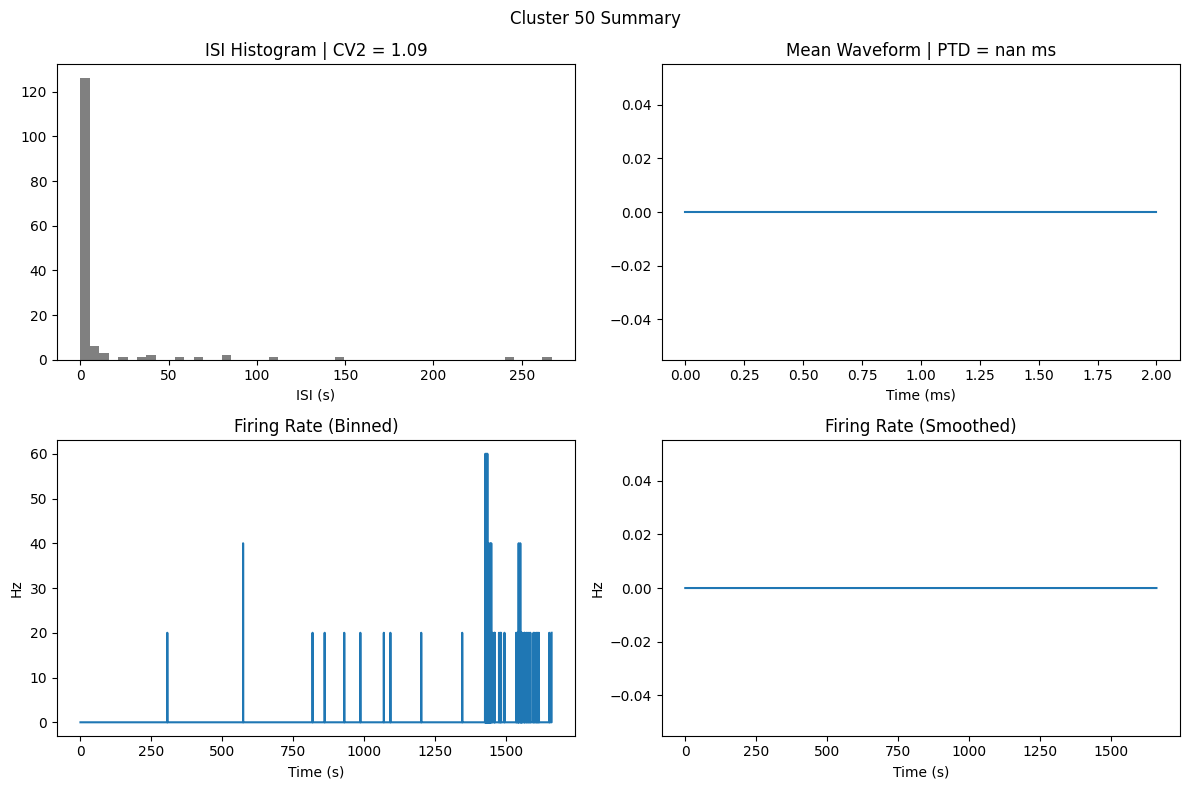

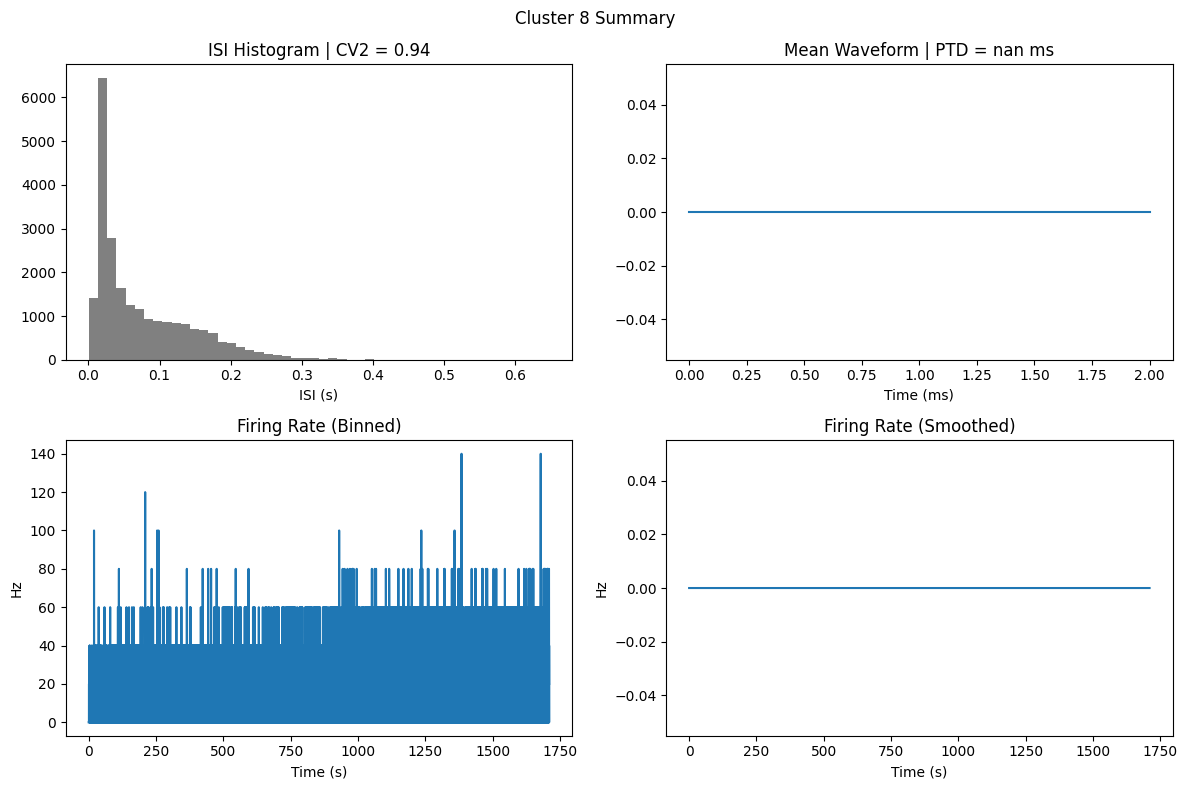

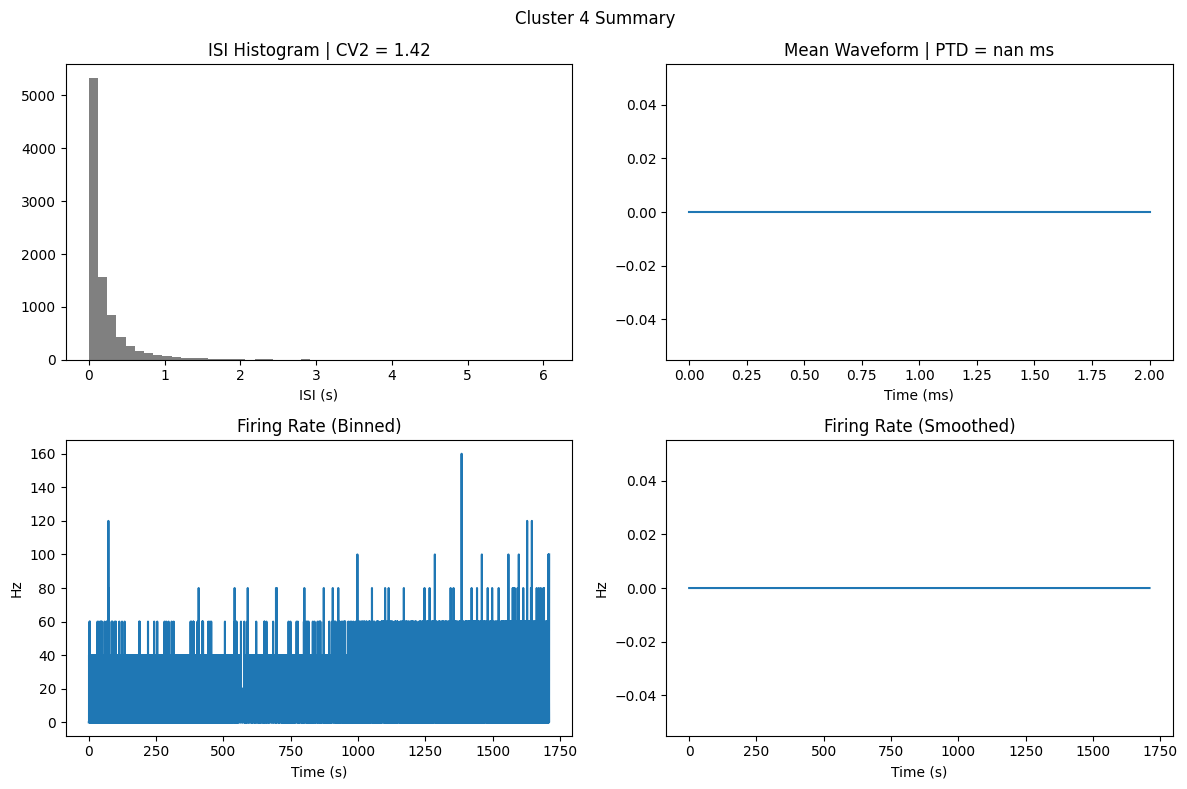

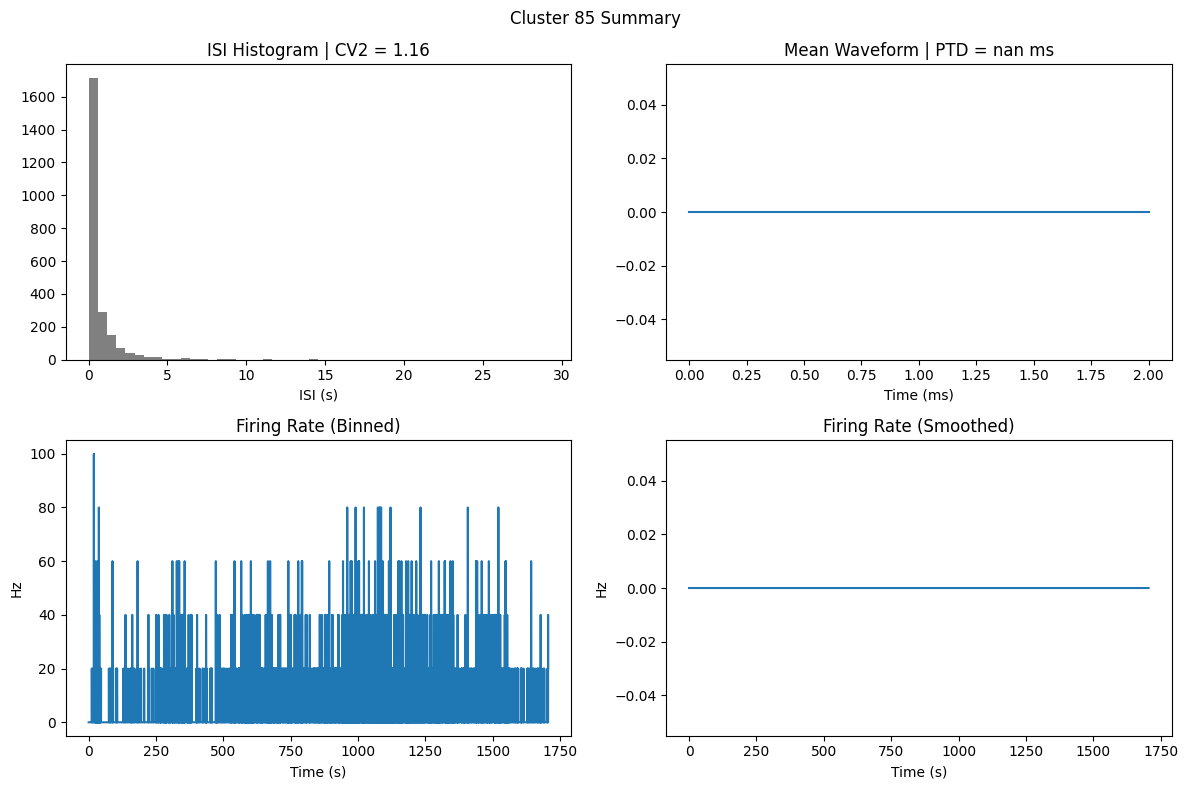

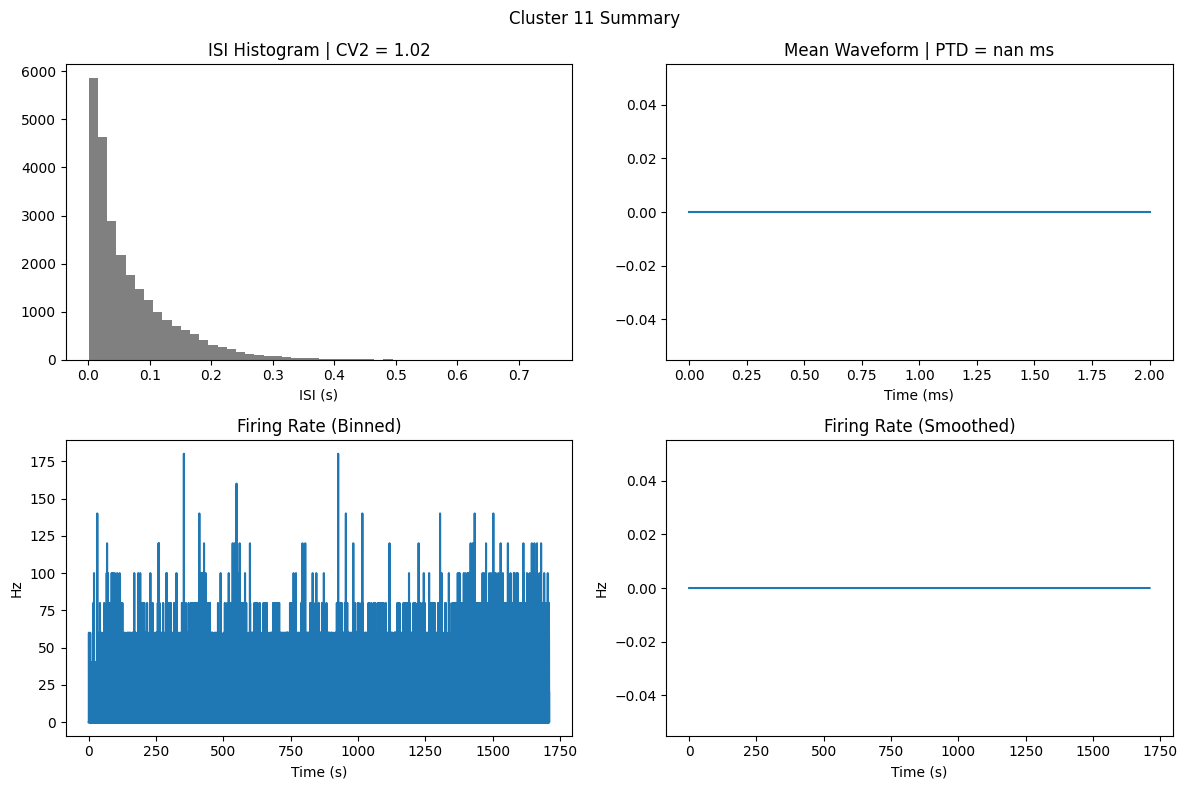

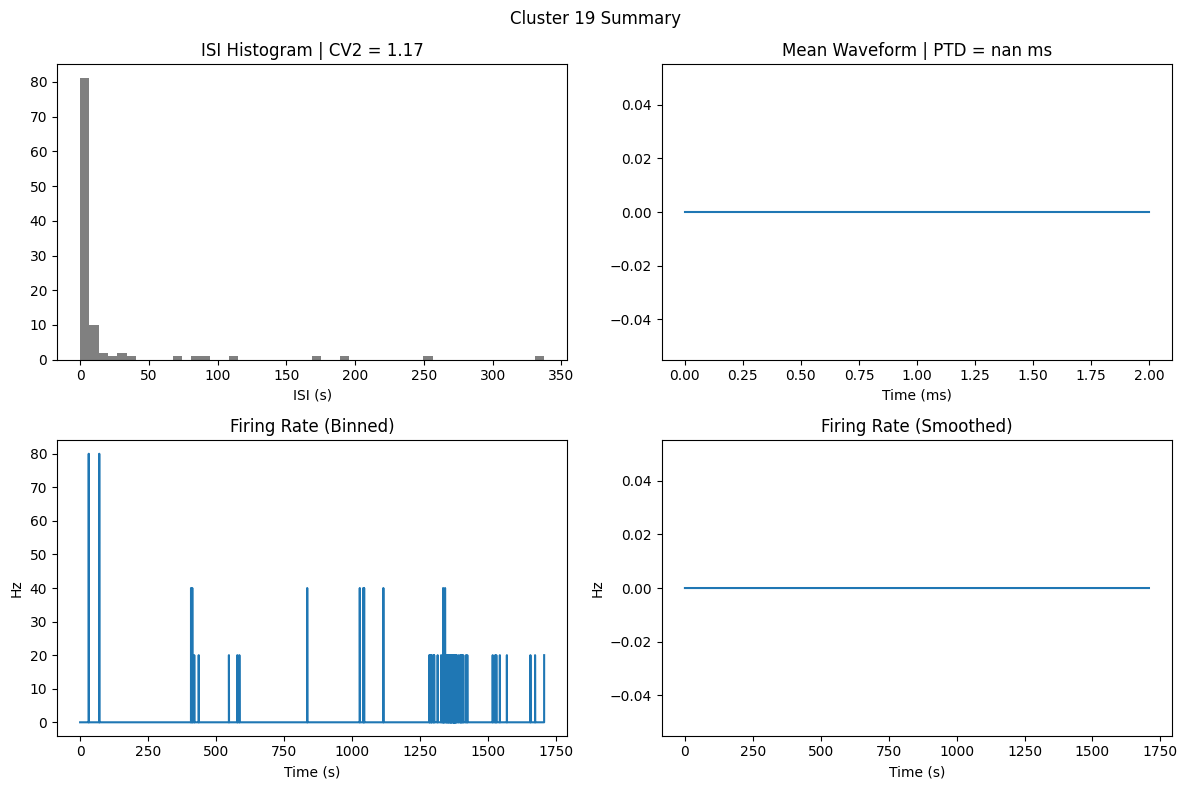

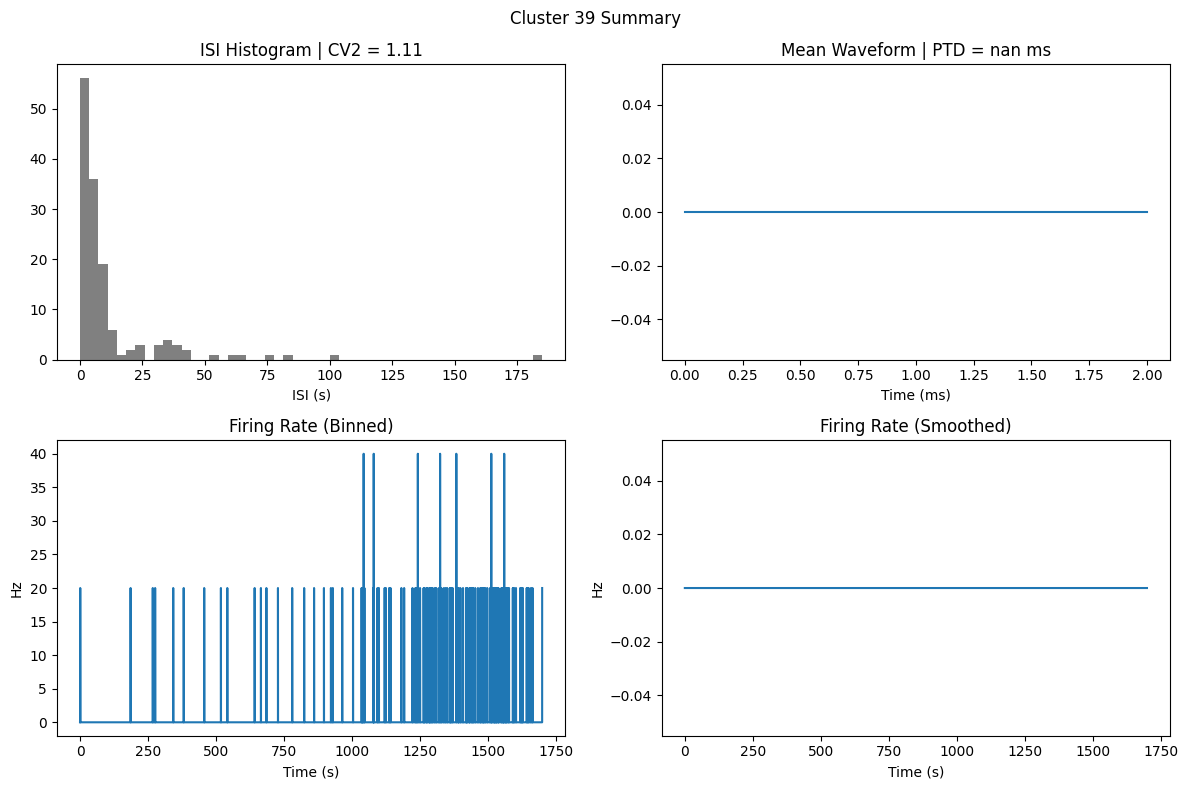

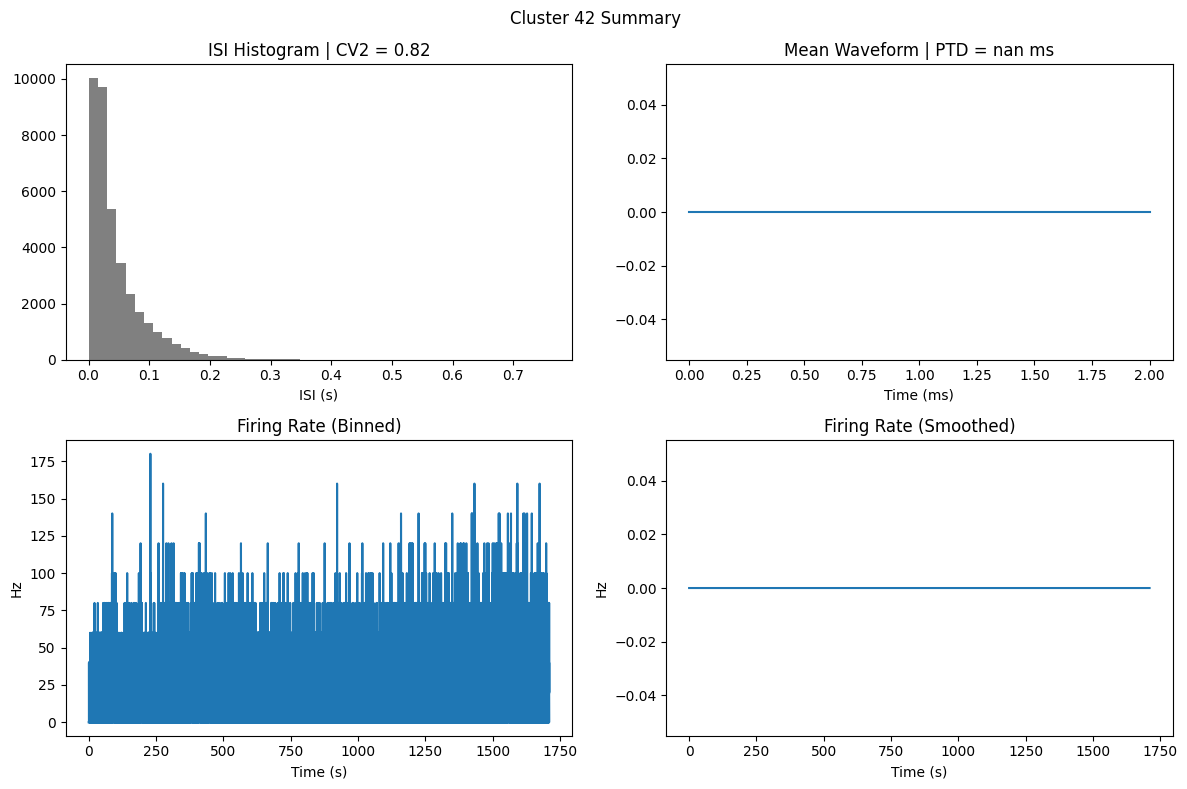

In [25]:
results_dir = Path('E:\PTEN\M1_s2\kilosort_tl6_tu7_fs30000.0')

run_pipeline(results_dir)
